# Pancreatic Cancer Prediction in Classification

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



# Read the CSV file and Analysis the data and which going to output

In [3]:
dataset = pd.read_csv("Pancreatic_Cancer.csv")

# First - Data Cleaning

In [4]:
print("No of Rows and Columns: ",dataset.shape)
print("Duplicate values: ", dataset.duplicated().sum())
null_columns = dataset.isnull().sum()
print("Missing Values: ", null_columns[null_columns > 0])
# ---------------- Drop ID column ----------------
dataset = dataset.drop(columns=['Patient_ID'])

No of Rows and Columns:  (60000, 132)
Duplicate values:  0
Missing Values:  Series([], dtype: int64)


# Convert the all categorical data into numerical data

In [5]:
# ---------------- Encode Target (Ordinal - has natural order) ----------------
# One-Hot Encoding for categorical data - Newyork, Texas, New jersey
# Label Encoding-  Binary categories like yes/No, True/False
# Ordinal Encoding - low, high, medium
# Here predict different stages of disease present or not. use Ordinal Encoding
stageOrder = [['Healthy', 'High Risk', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']]
encoder = OrdinalEncoder(categories=stageOrder)
dataset['Cancer_Stage'] = encoder.fit_transform(dataset[['Cancer_Stage']])

# ---------------- Encode remaining categorical features (One-Hot encoding) ----------------
dataset = pd.get_dummies(dataset, drop_first=True, dtype=int)

# Split input and Output and Finally Split the Train and Test Set

In [6]:
independent = dataset.drop(columns=["Cancer_Stage"], axis=1)
dependent = dataset["Cancer_Stage"]

#stratify=dependent  preserves the target class distribution in both the training and testing datasets.

X_train, X_test, Y_train, Y_test = train_test_split(
    independent, dependent, test_size=0.30, random_state=0, stratify=dependent
)

# Check the Output Class and how much balance or not balanced

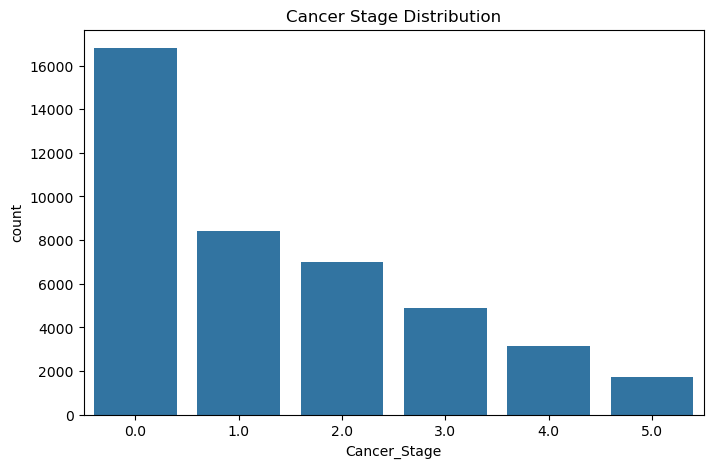

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x="Cancer_Stage", data=Y_train.to_frame())
plt.title("Cancer Stage Distribution")
plt.show()

# Based that images, the output having 6 class, which are 'Healthy', 'High Risk', 'Stage I', 'Stage II', 'Stage III', 'Stage IV' and make it balanced one using smote technique

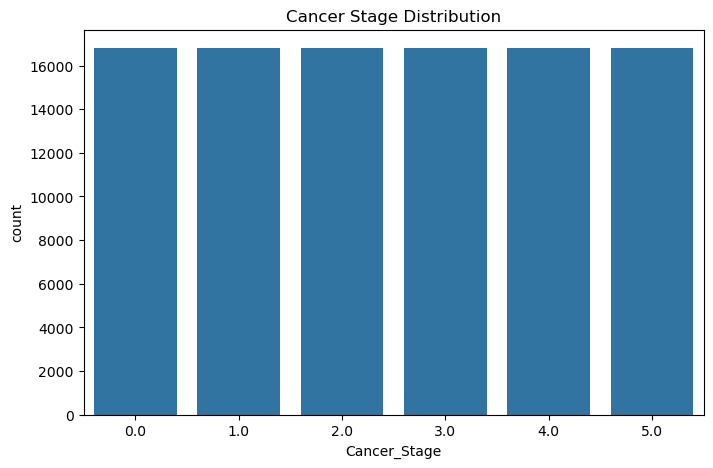

In [8]:
# ---------------- Handle Class Imbalance (train set only) ----------------
smote = SMOTE(random_state=42)
X_train_balance, Y_train_balance = smote.fit_resample(X_train, Y_train)

plt.figure(figsize=(8,5))
sns.countplot(x="Cancer_Stage", data=Y_train_balance.to_frame())
plt.title("Cancer Stage Distribution")
plt.show()


# Based that images, the output having 6 class are balanced one using smote technique and choose the best feature from this and recreate the input and output and split the train and test set again from new input and output

In [10]:
# ---------------- Feature Selection ----------------
selector = SelectKBest(score_func=f_classif, k=7)
selector.fit_transform(X_train_balance, Y_train_balance)

# Get the names of the selected columns
selected_features = independent.columns[selector.get_support()]
print(selected_features)

X =dataset[selected_features]
Y =dataset["Cancer_Stage"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.30, random_state=0, stratify=Y
)

Index(['Demographic_3', 'Lifestyle_7', 'Symptom_20', 'Lab_14', 'Imaging_11',
       'Imaging_12', 'Genetic_4'],
      dtype='object')


# Again use the SMOTE technique to identify the class is balance or not 

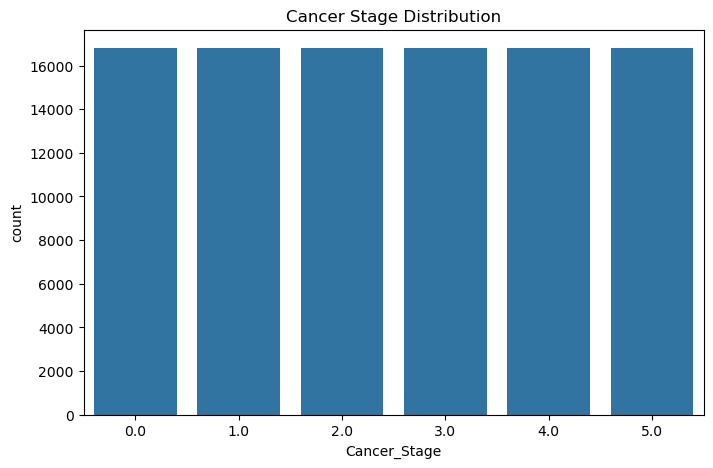

In [11]:
X_train_balance, Y_train_balance = smote.fit_resample(X_train, Y_train)

plt.figure(figsize=(8,5))
sns.countplot(x="Cancer_Stage", data=Y_train_balance.to_frame())
plt.title("Cancer Stage Distribution")
plt.show()


# Now use Standard Scalar

In [12]:
# ---------------- Scale ----------------
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train_balance)
X_test_scaled = sc.transform(X_test)

# Check the Model and Predict 

In [14]:
# ---------------- Feature Importance (Random Forest) ----------------
# Check with all algorithm, Random forest best result
classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier.fit(X_train_scaled, Y_train_balance)

# ---------------- Predict ----------------
Y_pred = classifier.predict(X_test_scaled)
Y_pred


array([0., 5., 3., ..., 1., 0., 0.], shape=(18000,))

In [15]:
# ---------------- Evaluate ----------------
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

Accuracy: 0.8615555555555555

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      7200
         1.0       0.89      0.94      0.91      3600
         2.0       0.83      0.84      0.83      3000
         3.0       0.71      0.66      0.69      2100
         4.0       0.58      0.47      0.52      1350
         5.0       0.56      0.54      0.55       750

    accuracy                           0.86     18000
   macro avg       0.76      0.74      0.75     18000
weighted avg       0.85      0.86      0.86     18000

